# Интерпретация моделей машинного обучения

Возьмем готовую коллекцию данных про остров тепла Москвы (DUHI)


In [148]:
import pandas as pd 
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt

from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, cross_val_score
from sklearn.model_selection import ShuffleSplit, KFold

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression

### Читаем данные, удаляем лишнее

In [149]:

df = pd.read_csv ("../datasets/DUHI/Moscow_basic.csv", sep=';', parse_dates=['time'], index_col=['time'])
df = df.drop(columns = [c for c in df.columns if ('delta' in c and c != 'delta_t2m_id27605') or 'rur' in c])

display(df.head())
display(df.describe())



C:\Users\mvar9\AppData\Local\Temp\ipykernel_30896\1091140751.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv ("../datasets/DUHI/Moscow_basic.csv", sep=';', parse_dates=['time'], index_col=['time'])


,delta_t2m_id27605,ERA5_t2m,ERA5_ps,ERA5_u10m,ERA5_v10m,ERA5_tcc,ERA5_lcc,ERA5_blh,ERA5_str,ERA5_ssr,ERA5_ssrd,ERA5_strd,ERA5_vel10m,ERA5_dir10,ERA5_tp_3h,ERA5_rh2m
time,,,,,,,,,,,,,,,,
2012-01-01 00:00:00,1.13,-1.30,988.57,-2.03,0.49,1.00,0.97,196.13,-7.85,0.00,0.00,301.78,2.09,103.55,0.27,97.01
2012-01-01 03:00:00,0.63,-1.38,987.99,-1.42,-0.18,1.00,1.00,165.84,-5.97,0.00,0.00,302.89,1.43,82.61,1.04,97.35
2012-01-01 06:00:00,0.93,-1.77,988.28,0.75,0.61,1.00,0.93,112.22,-12.21,0.00,0.00,293.34,0.96,230.87,0.62,97.97
2012-01-01 09:00:00,0.87,-1.71,989.51,2.42,1.56,0.94,0.88,307.48,-32.96,41.58,85.21,275.55,2.88,237.26,0.39,96.23
2012-01-01 12:00:00,0.69,-1.29,990.67,0.92,0.96,0.71,0.67,231.04,-19.30,24.45,49.29,290.98,1.32,223.83,0.09,93.68


,delta_t2m_id27605,ERA5_t2m,ERA5_ps,ERA5_u10m,ERA5_v10m,ERA5_tcc,ERA5_lcc,ERA5_blh,ERA5_str,ERA5_ssr,ERA5_ssrd,ERA5_strd,ERA5_vel10m,ERA5_dir10,ERA5_tp_3h,ERA5_rh2m
count,34071.000000,34088.000000,34088.000000,34088.000000,34088.000000,34088.000000,34088.000000,34088.000000,34085.000000,34085.000000,34085.000000,34085.000000,34088.000000,34088.000000,34085.000000,34088.000000
mean,2.002391,5.963003,994.353188,0.718380,0.378190,0.707743,0.452457,589.920067,-46.655100,98.054006,119.940783,300.398773,3.509172,199.344678,0.241138,75.950203
std,1.707798,10.755316,10.002078,2.582795,2.731026,0.355778,0.420196,489.975471,31.188789,160.686015,189.469910,49.429923,1.572797,96.824919,0.682190,18.114128
min,-6.290000,-34.700000,947.650000,-7.770000,-9.910000,0.000000,0.000000,11.240000,-150.690000,0.000000,0.000000,129.900000,0.010000,0.010000,0.000000,13.230000
25%,0.920000,-1.480000,988.160000,-1.170000,-1.640000,0.440000,0.010000,226.407500,-69.510000,0.000000,0.000000,269.380000,2.290000,131.347500,0.000000,65.500000
50%,1.480000,5.600000,994.290000,0.820000,0.490000,0.910000,0.340000,463.380000,-44.640000,4.750000,6.410000,302.620000,3.340000,210.845000,0.010000,81.430000
75%,2.600000,14.460000,1000.450000,2.540000,2.380000,1.000000,0.940000,801.395000,-18.710000,130.300000,172.380000,336.840000,4.530000,275.875000,0.140000,90.130000
max,11.470000,32.940000,1032.620000,11.550000,9.520000,1.000000,1.000000,3293.050000,14.180000,711.730000,830.450000,422.140000,11.850000,360.000000,14.910000,100.010000


### Немного feature engineering

<Axes: >

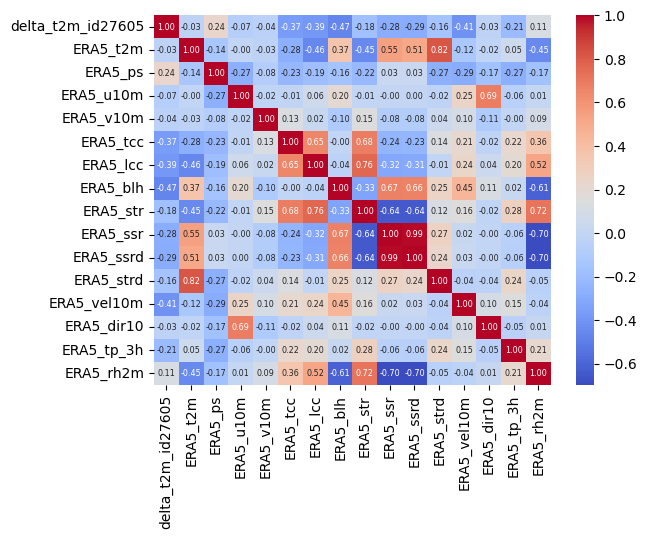

In [150]:
sns.heatmap (df.corr(), annot=True, cmap="coolwarm", fmt=".2f", annot_kws={'size': 'xx-small'})

### Сравниваем несколько моделей в подходе кросс-валидации

In [151]:
target = 'delta_t2m_id27605'
df4ml = df.dropna().sample(2000)
X = df4ml.drop (columns=[target])
Y = df4ml[target]

models = [LinearRegression (), 
          RandomForestRegressor (),
          GradientBoostingRegressor ()] 

cv = ShuffleSplit (n_splits=5, random_state = 42)

normalization = True

cv_results = {}

for model in tqdm(models):

    model_pp = Pipeline([
                        ('scaler', StandardScaler(with_mean=normalization, with_std=normalization)),
                        ('regressor', model)
                        ])

    cur_cv_results = cross_validate(model_pp, X, Y, cv=cv, n_jobs=8,
                                   scoring=['r2', 'neg_root_mean_squared_error'],
                                   return_train_score = True, return_estimator=True, return_indices=True)

    cur_cv_results['train_idx'] = cur_cv_results['indices']['train']
    cur_cv_results['test_idx'] = cur_cv_results['indices']['test']
    cur_cv_results.pop('indices')
    
    cur_cv_results['model'] = model.__class__.__name__
    cv_results[model.__class__.__name__] = cur_cv_results


100%|██████████| 3/3 [00:11<00:00,  3.93s/it]


### Собираем результаты кросс-валидации в DataFrame

In [152]:
cv_results_df = pd.concat ([pd.DataFrame(cv_results[model]) for model in cv_results.keys()], ignore_index=True)

cv_results_df['test_rmse'] = -cv_results_df['test_neg_root_mean_squared_error']
cv_results_df['train_rmse'] = -cv_results_df['train_neg_root_mean_squared_error']

cv_results_df.head()



,fit_time,score_time,estimator,test_r2,train_r2,test_neg_root_mean_squared_error,train_neg_root_mean_squared_error,train_idx,test_idx,model,test_rmse,train_rmse
0,0.089159,0.006773,"(StandardScaler(), LinearRegression())",0.475391,0.528000,-1.100162,-1.155556,"[1872, 526, 173, 720, 414, 237, 1472, 1335, 10...","[1860, 353, 1333, 905, 1289, 1273, 938, 1731, ...",LinearRegression,1.100162,1.155556
1,0.118120,0.004216,"(StandardScaler(), LinearRegression())",0.525906,0.522095,-1.312928,-1.131083,"[292, 1781, 1055, 1817, 185, 1923, 1572, 395, ...","[1829, 409, 1513, 863, 1867, 70, 1017, 1709, 6...",LinearRegression,1.312928,1.131083
2,0.118120,0.004216,"(StandardScaler(), LinearRegression())",0.528899,0.523043,-1.247081,-1.138591,"[1611, 791, 1758, 1269, 797, 8, 1536, 1417, 88...","[1186, 34, 1324, 955, 324, 1370, 130, 1484, 12...",LinearRegression,1.247081,1.138591
3,0.089159,0.006773,"(StandardScaler(), LinearRegression())",0.551719,0.521033,-1.124976,-1.152150,"[1009, 101, 431, 1346, 1531, 686, 980, 1718, 5...","[302, 229, 287, 1142, 1645, 737, 1568, 1190, 1...",LinearRegression,1.124976,1.152150
4,0.118120,0.004216,"(StandardScaler(), LinearRegression())",0.566450,0.518589,-1.091187,-1.156285,"[771, 1072, 316, 552, 1319, 1036, 983, 276, 56...","[1475, 4, 342, 1350, 415, 921, 599, 665, 504, ...",LinearRegression,1.091187,1.156285


## Строим диаграммы рассеяния для разных моделей и выборок (train/test) по всем итерациям кросс-валидации

In [153]:
reg_results = []

for i in cv_results_df.index:
    train_idx = cv_results_df.loc[i, 'train_idx']
    test_idx =  cv_results_df.loc[i, 'test_idx']
    
    cur_Y_train = Y.iloc[train_idx]
    cur_Y_test  = Y.iloc[test_idx]

    cur_X_train = X.iloc[train_idx]
    cur_X_test  = X.iloc[test_idx]

    cur_Y_train_pred = cv_results_df.loc[i, 'estimator'].predict(cur_X_train)
    cur_Y_test_pred  = cv_results_df.loc[i, 'estimator'].predict(cur_X_test)
    
    reg_results.append (pd.DataFrame({'Y':cur_Y_train, 'Y_pred':cur_Y_train_pred, 'model': cv_results_df.loc[i,'model'], 'type': 'train'}))
    reg_results.append (pd.DataFrame({'Y':cur_Y_test,  'Y_pred':cur_Y_test_pred,  'model': cv_results_df.loc[i,'model'], 'type': 'test'}))
    
reg_results = pd.concat(reg_results)

<Figure size 640x480 with 0 Axes>

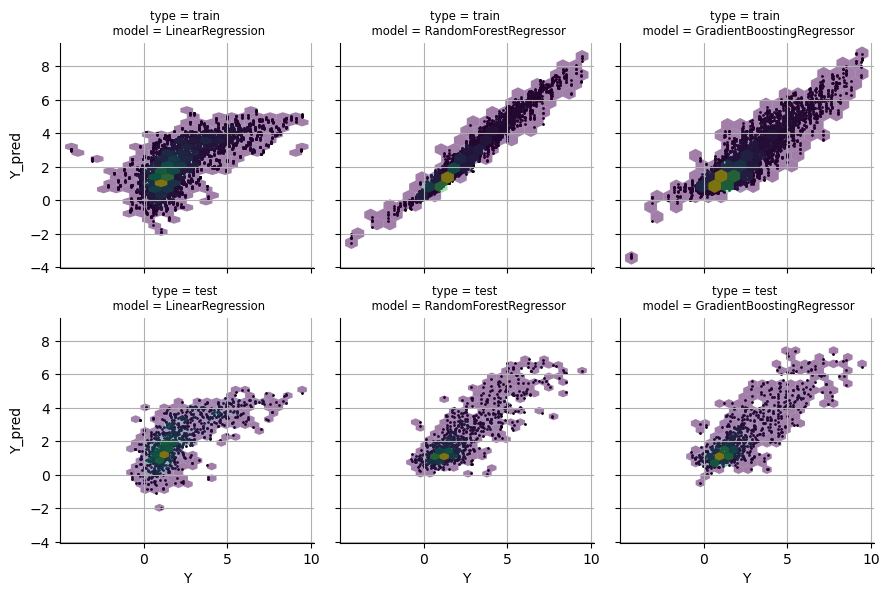

In [154]:
def myhexbin(*args, **kwargs):
        kwargs.pop("color", None)
        hb = plt.hexbin(*args, **kwargs)
        return hb

plt.figure()
g = sns.FacetGrid (reg_results, col = 'model', row='type')
g.map(plt.scatter, 'Y', 'Y_pred', s=1, color = 'black') 
g.map(myhexbin, 'Y', 'Y_pred', mincnt=1, gridsize=18, alpha = 0.5, edgecolor = None) 

for ax in g.axes.flatten():
        ax.set_title(ax.title.get_text().replace('|', '\n'), fontsize='small')
        ax.set_aspect(1) #'equal')
        ax.grid(zorder=0)



In [ ]:
#cv_results_df.iloc[11]['estimator']['regressor'].feature_importances_.sum()

1.0000000000000004

### Сравним значимость признаков в подходе кросс-валидации

Пока кросс-валидация для быстроты самая примитивная, подразумеваем, что может заменить ее на Bootstap. 

In [164]:
def extract_importance (cv_results_df, model_name,importance_attr):
    imp_df =  pd.concat([pd.DataFrame({'importance':getattr(model['regressor'], importance_attr),
                                       'model': model_name,
                                       'feature': X.columns}) for model in cv_results_df[cv_results_df['model'] == model_name]['estimator']])
    imp_df['importance'] = np.abs(imp_df['importance']) / np.sum(np.abs(imp_df['importance']))
    return imp_df

imp_gbr = extract_importance(cv_results_df, 'GradientBoostingRegressor', 'feature_importances_')
imp_rfr = extract_importance(cv_results_df, 'RandomForestRegressor', 'feature_importances_')
imp_lr = extract_importance(cv_results_df, 'LinearRegression', 'coef_')

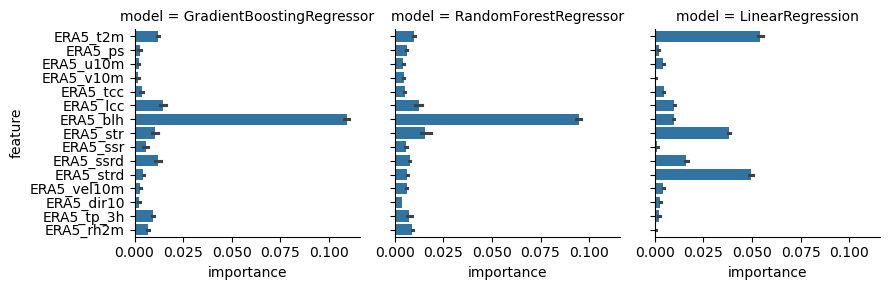

In [165]:
imp_all = pd.concat([imp_gbr, imp_rfr, imp_lr], axis=0)

g = sns.FacetGrid (imp_all, col = 'model')
g.map (sns.barplot, 'importance', 'feature', order = X.columns)


### Применим метод permutation_importance

In [170]:
from sklearn.inspection import permutation_importance

feature_importance = []

for i in tqdm (cv_results_df.index):
    cur_Y_test  = Y.iloc[cv_results_df.loc[i, 'test_idx']]
    cur_X_test  = X.iloc[cv_results_df.loc[i, 'test_idx']]

    result = permutation_importance(cv_results_df.loc[i, 'estimator'], cur_X_test, cur_Y_test, n_repeats=5,
                                    random_state=0, n_jobs = 8, scoring='r2')

    feature_importance.append(pd.DataFrame({'importance': result['importances_mean']/np.sum(result['importances_mean']),
                                            'model': cv_results_df['model'][i], 'feature': X.columns}))   

feature_importance = pd.concat(feature_importance)

100%|██████████| 15/15 [00:22<00:00,  1.47s/it]


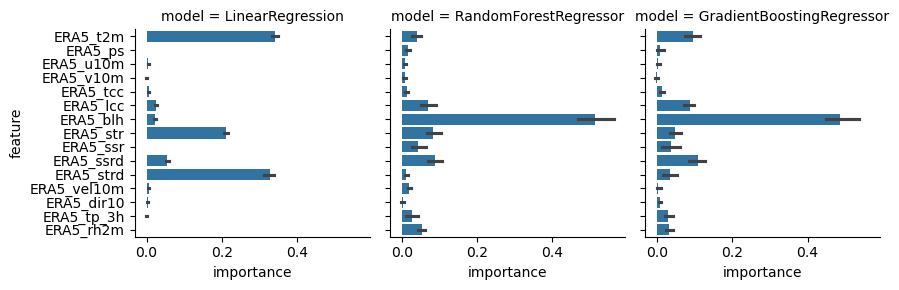

In [168]:
g = sns.FacetGrid (feature_importance, col = 'model', col_wrap=3)
g.map (sns.barplot, 'importance', 'feature', order = X.columns)

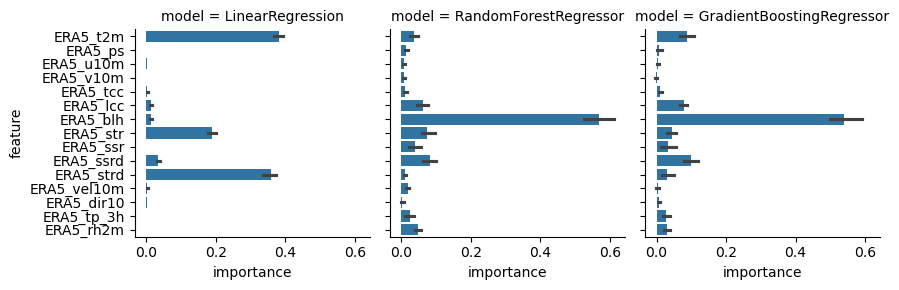

In [171]:
g = sns.FacetGrid (feature_importance, col = 'model', col_wrap=3)
g.map (sns.barplot, 'importance', 'feature', order = X.columns)